<a href="https://colab.research.google.com/github/bananmagdy3-crypto/Netflix/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**importing libraries**

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**importing Files**

In [4]:
df = pd.read_excel('/content/drive/MyDrive/Netflix.xlsx')
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,2021-12-15 00:00:00,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,NaN,NaN,NaN,NaN,NaN
1,2022-03-01 00:00:00,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,NaN,NaN,NaN,NaN,NaN
2,2022-02-25 00:00:00,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,NaN,NaN,NaN,NaN,NaN
3,2021-11-24 00:00:00,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,NaN,NaN,NaN,NaN,NaN
4,2021-12-22 00:00:00,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842,1973-10-15 00:00:00,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,NaN,NaN,NaN,NaN,NaN
9843,2020-10-01 00:00:00,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,NaN,NaN,NaN,NaN,NaN
9844,2016-05-06 00:00:00,The Offering,When young and successful reporter Jamie finds...,13.355,94,5,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,NaN,NaN,NaN,NaN,NaN
9845,2021-03-31 00:00:00,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9847 entries, 0 to 9846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Release_Date       9847 non-null   object
 1   Title              9838 non-null   object
 2   Overview           9837 non-null   object
 3   Popularity         9644 non-null   object
 4   Vote_Count         9644 non-null   object
 5   Vote_Average       9643 non-null   object
 6   Original_Language  9643 non-null   object
 7   Genre              9640 non-null   object
 8   Poster_Url         9639 non-null   object
 9   Unnamed: 9         9 non-null      object
 10  Unnamed: 10        4 non-null      object
 11  Unnamed: 11        2 non-null      object
 12  Unnamed: 12        2 non-null      object
 13  Unnamed: 13        1 non-null      object
dtypes: object(14)
memory usage: 1.1+ MB


In [10]:
df[['Popularity' , 'Vote_Count' , 'Vote_Average']].describe().round(2)

,Popularity,Vote_Count,Vote_Average
count,9644.0,9644,9643.0
unique,8037.0,3250,85.0
top,14.7,0,6.5
freq,6.0,100,423.0


**preprocessing**

In [6]:
print(df.isnull().sum())

Release_Date            0
Title                   9
Overview               10
Popularity            203
Vote_Count            203
Vote_Average          204
Original_Language     204
Genre                 207
Poster_Url            208
Unnamed: 9           9838
Unnamed: 10          9843
Unnamed: 11          9845
Unnamed: 12          9845
Unnamed: 13          9846
dtype: int64


In [11]:
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# Fill missing values with the mean of each column
df['Popularity'].fillna(df['Popularity'].mean(), inplace=True)
df['Vote_Count'].fillna(df['Vote_Count'].mean(), inplace=True)
df['Vote_Average'].fillna(df['Vote_Average'].mean(), inplace=True)

/tmp/ipykernel_520/3674584308.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Popularity'].fillna(df['Popularity'].mean(), inplace=True)
/tmp/ipykernel_520/3674584308.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [13]:
print(df.isnull().sum())

Release_Date            0
Title                   9
Overview               10
Popularity              0
Vote_Count              0
Vote_Average            0
Original_Language     204
Genre                 207
Poster_Url            208
Unnamed: 9           9838
Unnamed: 10          9843
Unnamed: 11          9845
Unnamed: 12          9845
Unnamed: 13          9846
dtype: int64


In [16]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['Date'] = pd.to_datetime(df['Release_Date'], format='%Y-%m-%d', errors='coerce')

In [32]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df

/tmp/ipykernel_520/1196107620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Date'].dt.year
/tmp/ipykernel_520/1196107620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Date,Year,Month,Day
0,2021-12-15 00:00:00,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954000,8940.000000,8.300000,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021-12-15,2021.0,12.0,15.0
1,2022-03-01 00:00:00,The Batman,"In his second year of fighting crime, Batman u...",3827.658000,1151.000000,8.100000,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022-03-01,2022.0,3.0,1.0
2,2022-02-25 00:00:00,No Exit,Stranded at a rest stop in the mountains durin...,2618.087000,122.000000,6.300000,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022-02-25,2022.0,2.0,25.0
3,2021-11-24 00:00:00,Encanto,"The tale of an extraordinary family, the Madri...",2402.201000,5076.000000,7.700000,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021-11-24,2021.0,11.0,24.0
4,2021-12-22 00:00:00,The King's Man,As a collection of history's worst tyrants and...,1895.511000,1793.000000,7.000000,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021-12-22,2021.0,12.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842,1973-10-15 00:00:00,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357000,896.000000,7.600000,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,1973-10-15,1973.0,10.0,15.0
9843,2020-10-01 00:00:00,Violent Delights,A female vampire falls in love with a man she ...,13.356000,8.000000,3.500000,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,2020-10-01,2020.0,10.0,1.0
9844,2016-05-06 00:00:00,The Offering,When young and successful reporter Jamie finds...,13.355000,94.000000,5.000000,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,2016-05-06,2016.0,5.0,6.0
9845,2021-03-31 00:00:00,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354000,152.000000,6.700000,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,2021-03-31,2021.0,3.0,31.0


In [33]:
print(df.columns.tolist())

['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url', 'Date', 'Year', 'Month', 'Day']


In [34]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Date,Year,Month,Day
0,2021-12-15 00:00:00,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954000,8940.000000,8.300000,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021-12-15,2021.0,12.0,15.0
1,2022-03-01 00:00:00,The Batman,"In his second year of fighting crime, Batman u...",3827.658000,1151.000000,8.100000,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022-03-01,2022.0,3.0,1.0
2,2022-02-25 00:00:00,No Exit,Stranded at a rest stop in the mountains durin...,2618.087000,122.000000,6.300000,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022-02-25,2022.0,2.0,25.0
3,2021-11-24 00:00:00,Encanto,"The tale of an extraordinary family, the Madri...",2402.201000,5076.000000,7.700000,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021-11-24,2021.0,11.0,24.0
4,2021-12-22 00:00:00,The King's Man,As a collection of history's worst tyrants and...,1895.511000,1793.000000,7.000000,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021-12-22,2021.0,12.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842,1973-10-15 00:00:00,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357000,896.000000,7.600000,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,1973-10-15,1973.0,10.0,15.0
9843,2020-10-01 00:00:00,Violent Delights,A female vampire falls in love with a man she ...,13.356000,8.000000,3.500000,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,2020-10-01,2020.0,10.0,1.0
9844,2016-05-06 00:00:00,The Offering,When young and successful reporter Jamie finds...,13.355000,94.000000,5.000000,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,2016-05-06,2016.0,5.0,6.0
9845,2021-03-31 00:00:00,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354000,152.000000,6.700000,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,2021-03-31,2021.0,3.0,31.0


**Analysis**

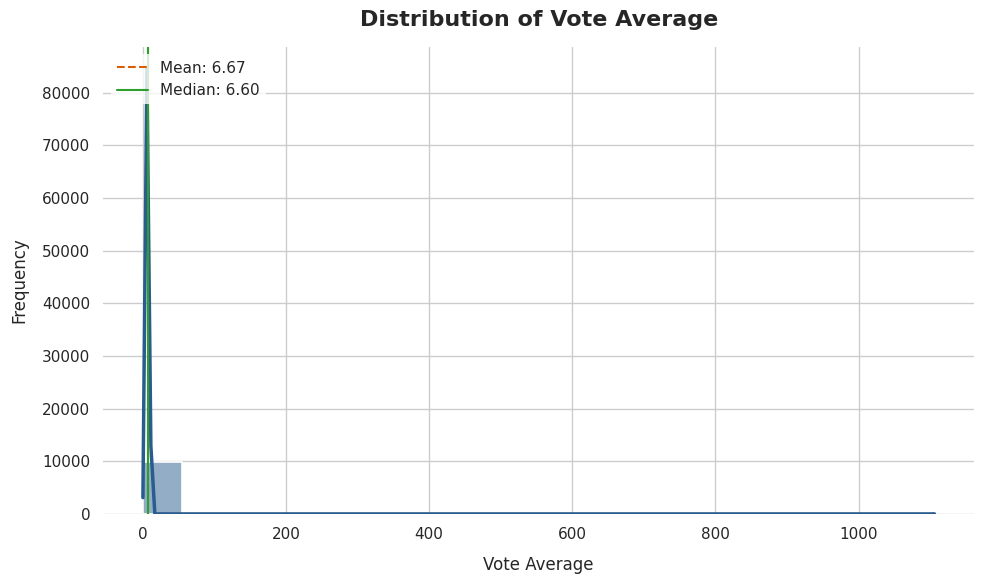

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
mean_val = df['Vote_Average'].mean()
median_val = df['Vote_Average'].median()


sns.histplot(
    df['Vote_Average'],
    kde=True,
    bins=20,
    color="#2b5c8f",
    edgecolor="white",
    linewidth=1.2,
    line_kws={"linewidth": 2.5, "color": "#d95f02"}
)

plt.axvline(mean_val, color='#d95f02', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#2ca02c', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')

plt.title('Distribution of Vote Average', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Vote Average', fontsize=12, labelpad=10)
plt.ylabel('Frequency', fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

/tmp/ipykernel_520/447916165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


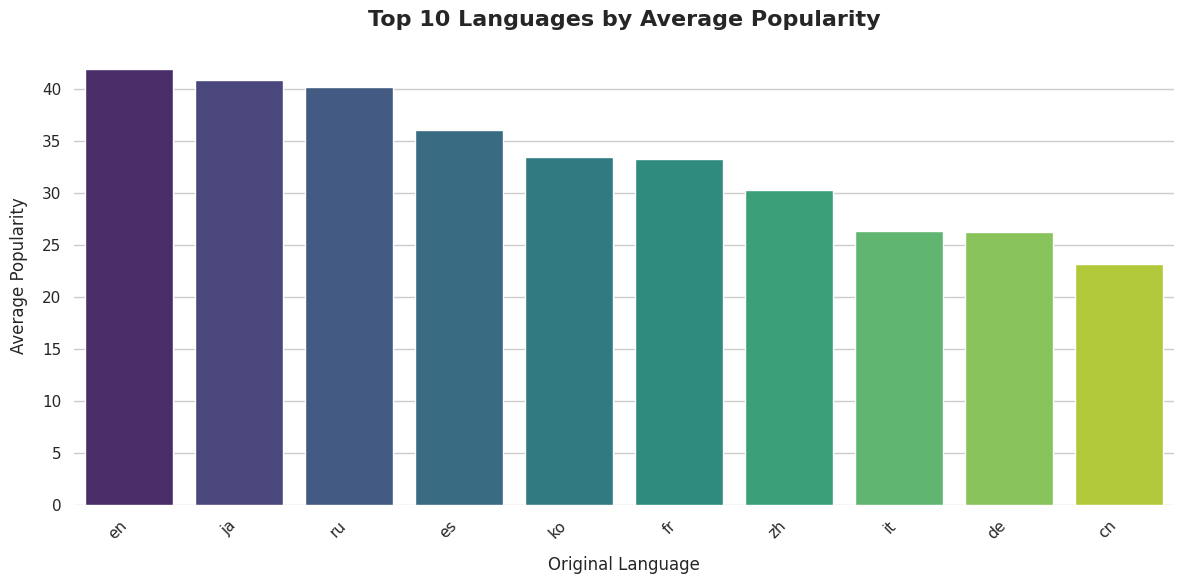

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
top_languages = df['Original_Language'].value_counts().nlargest(10).index
df_filtered = df[df['Original_Language'].isin(top_languages)]
group_order = df_filtered.groupby('Original_Language')['Popularity'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df_filtered,
    x='Original_Language',
    y='Popularity',
    order=group_order,
    palette="viridis",
    errorbar=None
)

plt.xticks(rotation=45, ha='right')

plt.title('Top 10 Languages by Average Popularity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Original Language', fontsize=12, labelpad=10)
plt.ylabel('Average Popularity', fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

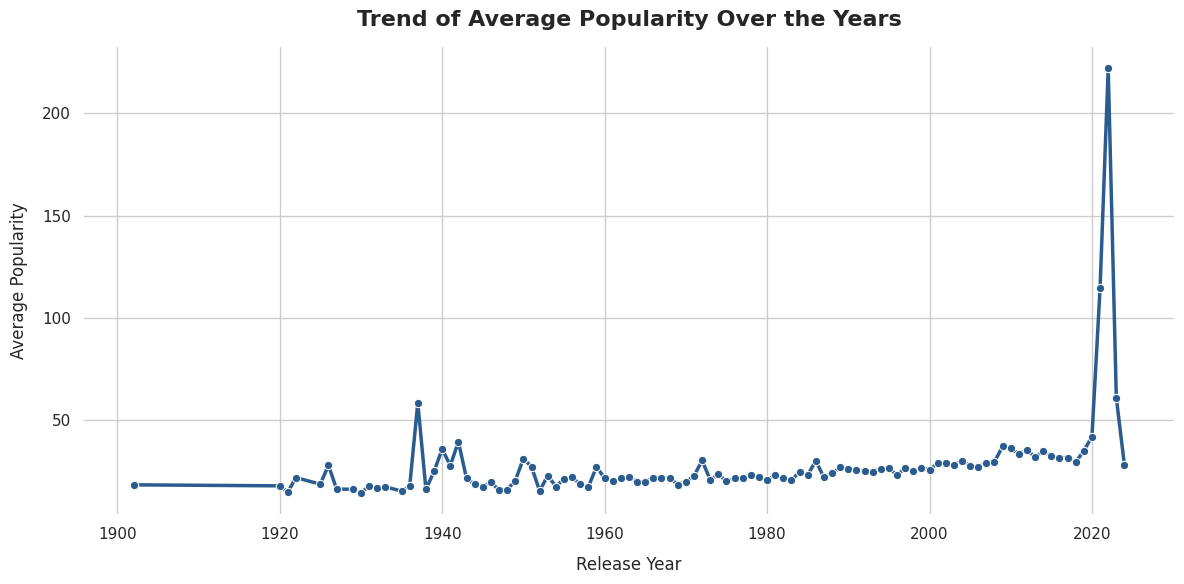

In [42]:
if 'Year' not in df.columns and 'release_date' in df.columns:
    df['Year'] = pd.to_datetime(df['release_date']).dt.year

yearly_popularity = df.groupby('Year')['Popularity'].mean().reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_popularity,
    x='Year',
    y='Popularity',
    marker='o',
    color='#2b5c8f',
    linewidth=2.5
)

plt.title('Trend of Average Popularity Over the Years', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Release Year', fontsize=12, labelpad=10)
plt.ylabel('Average Popularity', fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_520/3076659171.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


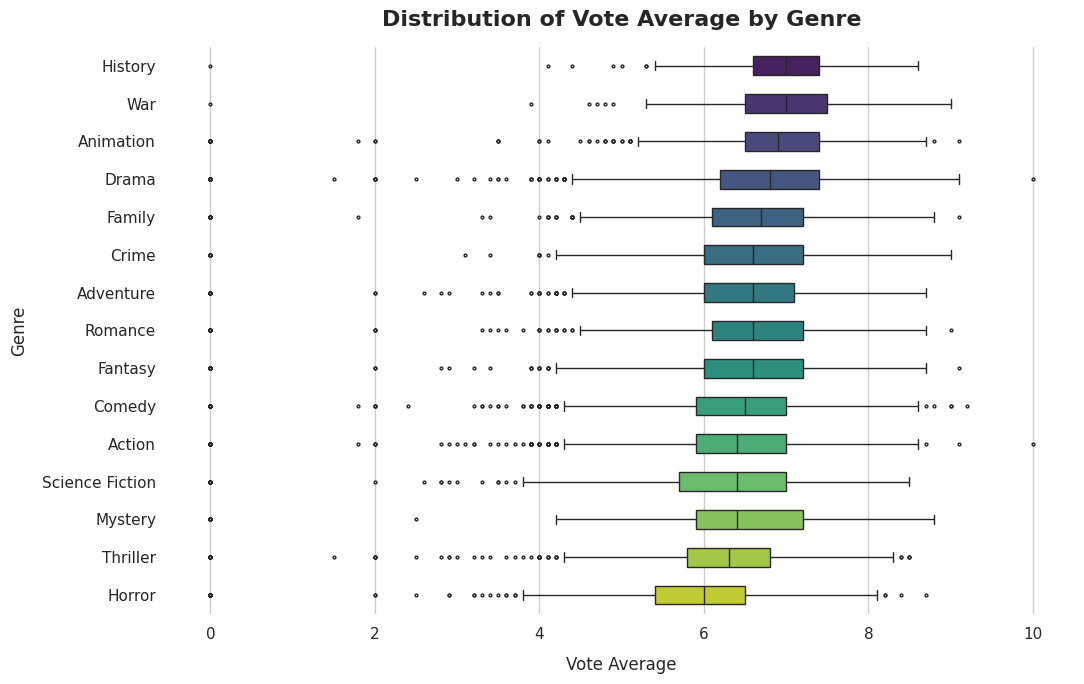

In [48]:
possible_names = ['genres', 'Genre', 'genre', 'genres_list']
genre_column = None

for name in possible_names:
    if name in df.columns:
        genre_column = name
        break

if genre_column is None:
    raise ValueError("Error")

df_plot = df.copy()

df_plot[genre_column] = df_plot[genre_column].fillna('')

df_plot[genre_column] = df_plot[genre_column].apply(lambda x: x.split(', ') if isinstance(x, str) and x != '' else [x])
df_plot = df_plot.explode(genre_column)

df_plot[genre_column] = df_plot[genre_column].astype(str).str.strip()
df_plot = df_plot[df_plot[genre_column] != '']
df_plot = df_plot[df_plot[genre_column].str.len() < 25]

top_genres = df_plot[genre_column].value_counts().nlargest(15).index
df_plot_filtered = df_plot[df_plot[genre_column].isin(top_genres)]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

genre_order = df_plot_filtered.groupby(genre_column)['Vote_Average'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_plot_filtered,
    y=genre_column,
    x='Vote_Average',
    order=genre_order,
    palette='viridis',
    width=0.5,
    fliersize=2
)
plt.title('Distribution of Vote Average by Genre', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Vote Average', fontsize=12, labelpad=10)
plt.ylabel('Genre', fontsize=12, labelpad=10)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [49]:
df.to_excel('Netflix_cleaned.xlsx', index=False)